# Using [ModeSimulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSimulation.html) for optical mode analysis

This tutorial shows how to use [ModeSimulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSimulation.html) in Tidy3D.

For a tutorial on the legacy [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) plugin, please refer to [this notebook](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html).

In [1]:
# standard python imports
import matplotlib.pylab as plt
import numpy as np

# tidy3D import
import tidy3d as td
import tidy3d.web as web
from tidy3d.constants import C_0

## Setup

We first set up the mode simulation with information about our system. We start by setting the parameters.

In [2]:
# size of simulation domain
Lx, Ly, Lz = 6, 6, 6
dl = 0.05

# waveguide information
wg_width = 1.5
wg_height = 1.0
wg_permittivity = 4.0

# central frequency
wvl_um = 2.0
freq0 = C_0 / wvl_um
fwidth = freq0 / 3

# run_time in ps
run_time = 1e-12

# automatic grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wvl_um)

We then define a [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html), in this case including a straight waveguide and periodic boundary conditions. Note that Tidy3D warns us that we have not added any sources to the [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) object. However, for mode solving, this is not necessary.

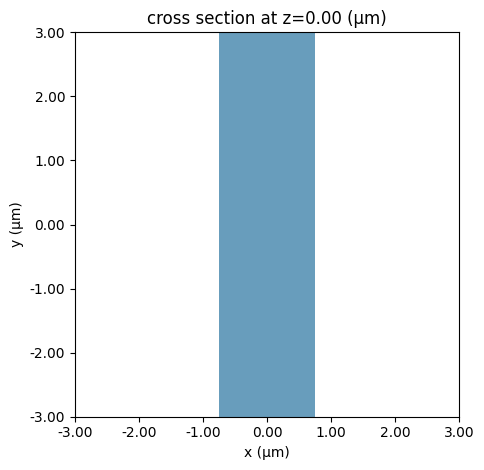

In [3]:
waveguide = td.Structure(
    geometry=td.Box(size=(wg_width, td.inf, wg_height)),
    medium=td.Medium(permittivity=wg_permittivity),
)

sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    structures=[waveguide],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
)

ax = sim.plot(z=0)
plt.show()

## Initialize Mode Simulation

With our system defined, we can now create our mode simulation. We first need to specify the plane on which we want to solve the modes using a [`td.Box()`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Box.html) object.


In [4]:
plane = td.Box(center=(0, 0, 0), size=(4, 0, 3.5))

The mode simulation can now compute the modes given a [`ModeSpec`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSpec.html) object that specifies everything about the modes we are looking for, for example:

- `num_modes`: how many modes to compute.
- `target_neff`: float, default = `None`, initial guess for the effective index of the mode; if not specified, the modes with the largest real part of the effective index are computed.

The full list of specification parameters can be found [here](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSpec.html#tidy3d.ModeSpec).

In [5]:
mode_spec = td.ModeSpec(
    num_modes=3,
    target_neff=2.0,
)

We can also specify a list of frequencies at which to solve for the modes.

In [6]:
num_freqs = 11
f0_ind = num_freqs // 2
freqs = np.linspace(freq0 - fwidth / 2, freq0 + fwidth / 2, num_freqs)

Finally, we can initialize the [`ModeSimulation`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSimulation.html) and call the local run method.

In [7]:
mode_simulation = td.ModeSimulation.from_simulation(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)
sim_data = mode_simulation.run_local()
mode_data = sim_data.modes

We can also summarize useful mode information using `to_dataframe()`. Note that the group index was not computed; this can be included by setting `group_index_step=True` in the [`ModeSpec`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSpec.html).

In [8]:
mode_data.to_dataframe()

wavelength     n eff  k eff  TE (Ex) fraction  \
f            mode_index                                                  
1.249135e+14 0             2.400000  1.686130    0.0          0.995963   
             1             2.400000  1.610272    0.0          0.010245   
             2             2.400000  1.294575    0.0          0.226877   
1.299101e+14 0             2.307692  1.706504    0.0          0.996620   
             1             2.307692  1.637271    0.0          0.008747   
             2             2.307692  1.339798    0.0          0.203097   
1.349066e+14 0             2.222222  1.724923    0.0          0.997149   
             1             2.222222  1.661620    0.0          0.007504   
             2             2.222222  1.381434    0.0          0.180304   
1.399031e+14 0             2.142857  1.741628    0.0          0.997578   
             1             2.142857  1.683633    0.0          0.006470   
             2             2.142857  1.419700    0.0          0.159137   
1.448997e+14 0             2.068966  1.756829    0.0          0.997929   
             1             2.068966  1.703585    0.0          0.005608   
             2             2.068966  1.454838    0.0          0.139924   
1.498962e+14 0             2.000000  1.770701    0.0          0.998217   
             1             2.000000  1.721718    0.0          0.004884   
             2             2.000000  1.487099    0.0          0.122766   
1.548928e+14 0             1.935484  1.783397    0.0          0.998457   
             1             1.935484  1.738240    0.0          0.004275   
             2             1.935484  1.516731    0.0          0.107623   
1.598893e+14 0             1.875000  1.795048    0.0          0.998656   
             1             1.875000  1.753333    0.0          0.003760   
             2             1.875000  1.543974    0.0          0.094364   
1.648859e+14 0             1.818182  1.805767    0.0          0.998824   
             1             1.818182  1.767156    0.0          0.003321   
             2             1.818182  1.569047    0.0          0.082819   
1.698824e+14 0             1.764706  1.815652    0.0          0.998965   
             1             1.764706  1.779845    0.0          0.002946   
             2             1.764706  1.592156    0.0          0.072798   
1.748789e+14 0             1.714286  1.824788    0.0          0.999086   
             1             1.714286  1.791520    0.0          0.002624   
             2             1.714286  1.613486    0.0          0.064114   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
1.249135e+14 0                 0.852047        0.891376   1.617419  
             1                 0.747363        0.926638   2.003675  
             2                 0.896083        0.622542   2.695683  
1.299101e+14 0                 0.862301        0.895654   1.539832  
             1                 0.759892        0.930604   1.882750  
             2                 0.888992        0.647089   2.457125  
1.349066e+14 0                 0.871672        0.899721   1.473564  
             1                 0.772128        0.934256   1.778317  
             2                 0.883673        0.670054   2.257857  
1.399031e+14 0                 0.880228        0.903585   1.416463  
             1                 0.783911        0.937626   1.687731  
             2                 0.880027        0.691309   2.090149  
1.448997e+14 0                 0.888036        0.907257   1.366859  
             1                 0.795151        0.940743   1.608796  
             2                 0.877877        0.710836   1.948159  
1.498962e+14 0                 0.895166        0.910747   1.323447  
             1                 0.805802        0.943631   1.539695  
             2                 0.877011        0.728694   1.827302  
1.548928e+14 0                 0.901682        0.91406

## Visualizing Mode Data

The `mode_info` object contains information about the effective index of the mode and the field profiles, as well as the `mode_spec` used in the solver. The effective index data and the field profile data are in the form of xarray DataArrays.

We can, for example, plot the real part of the effective index for all three modes as follows.

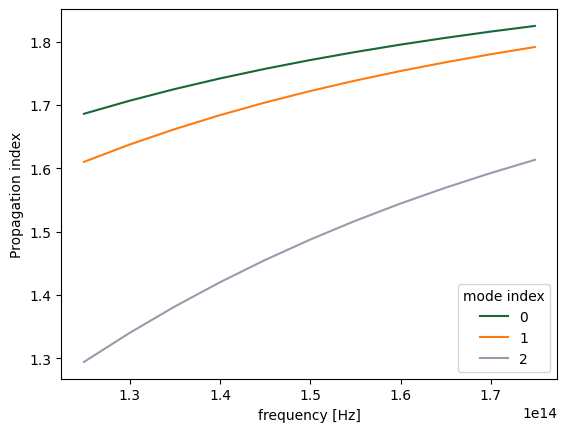

In [9]:
fig, ax = plt.subplots(1)
n_eff = mode_data.n_eff  # real part of the effective mode index
n_eff.plot.line(x="f")
plt.show()

The raw data can also be accessed.

In [10]:
n_complex = mode_data.n_complex  # complex effective index as a DataArray
n_eff = mode_data.n_eff.values  # real part of the effective index as numpy array
k_eff = mode_data.k_eff.values  # imag part of the effective index as numpy array

print(
    f"first mode effective index at freq0: n_eff = {n_eff[f0_ind, 0]:.2f}, k_eff = {k_eff[f0_ind, 0]:.2e}"
)

first mode effective index at freq0: n_eff = 1.77, k_eff = 0.00e+00


The fields stored in `mode_data` can be visualized using built-in xarray methods.

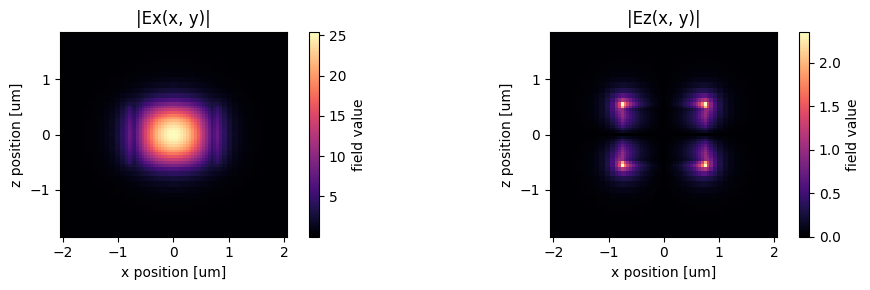

In [11]:
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
abs(mode_data.Ex.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ez.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax2, cmap="magma")

ax1.set_title("|Ex(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ez(x, y)|")
ax2.set_aspect("equal")
plt.show()

Alternatively, we can use the built-in `plot_field` method of `sim_data`, which also allows us to overlay the structures in the simulation. The image also looks slightly different because the `plot_field` method uses the `robust=True` option by default, which scales the colorbar between the 2nd and 98th percentiles of the data.

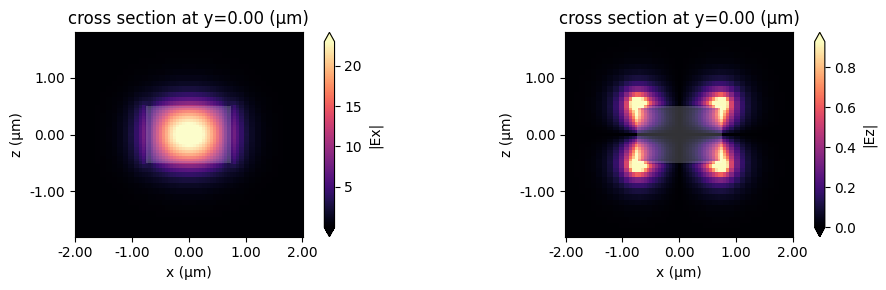

In [12]:
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
sim_data.plot_field("Ex", "abs", mode_index=0, f=freq0, ax=ax1)
sim_data.plot_field("Ez", "abs", mode_index=0, f=freq0, ax=ax2)
plt.show()

## Choosing the mode of interest

We can also look at the other modes that were computed.

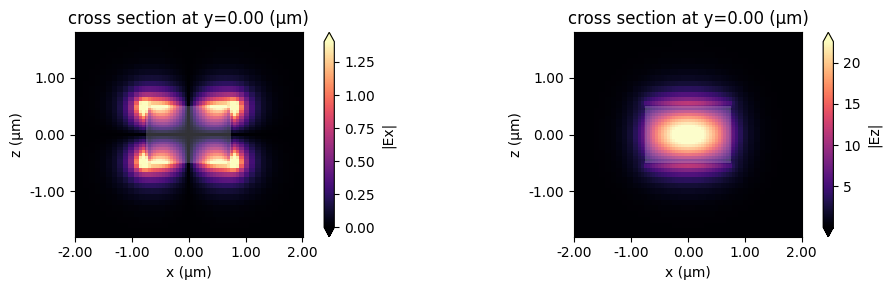

In [13]:
mode_index = 1
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
sim_data.plot_field("Ex", "abs", mode_index=mode_index, f=freq0, ax=ax1)
sim_data.plot_field("Ez", "abs", mode_index=mode_index, f=freq0, ax=ax2)
plt.show()

This looks like an Ez-dominant mode. Finally, the next-order mode has mixed polarization.

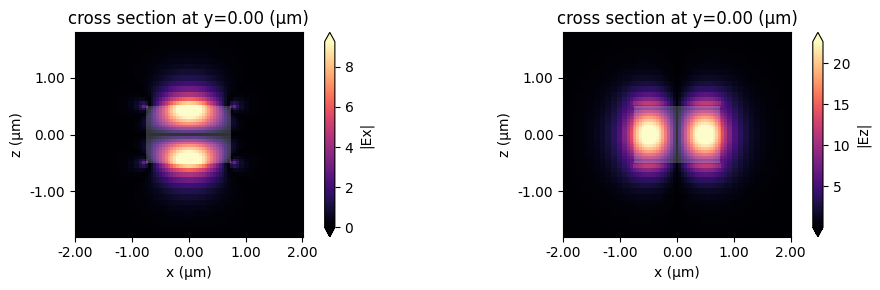

In [14]:
mode_index = 2
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
sim_data.plot_field("Ex", "abs", mode_index=mode_index, f=freq0, ax=ax1)
sim_data.plot_field("Ez", "abs", mode_index=mode_index, f=freq0, ax=ax2)
plt.show()

## Exporting Results

This looks promising!

Now we can choose the mode specifications to use in our mode source and mode monitors. These can be created separately, or they can be exported directly from the mode simulation, for example:

In [15]:
# Makes a modal source with geometry of `plane` with modes specified by `mode_spec` and a selected `mode_index`
source_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth)
mode_src = td.ModeSource(
    center=plane.center,
    size=plane.size,
    source_time=source_time,
    mode_spec=mode_spec,
    mode_index=2,
    direction="-",
)

# Makes a mode monitor with geometry of `plane`.
mode_mon = td.ModeMonitor(
    center=plane.center,
    size=plane.size,
    freqs=freqs,
    mode_spec=mode_spec,
    name="mode",
)
# Offset the monitor along the propagation direction
mode_mon = mode_mon.copy(update=dict(center=(0, -2, 0)))

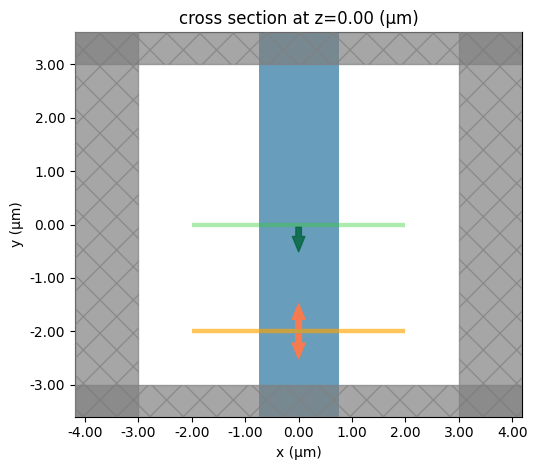

In [16]:
# In-plane field monitor, slightly offset along x
monitor = td.FieldMonitor(center=(0, 0, 0.1), size=(td.inf, td.inf, 0), freqs=[freq0], name="field")

# New monitor to record the modes computed at the mode decomposition monitor location
mode_solver_mon = td.ModeSolverMonitor(
    center=mode_mon.center,
    size=mode_mon.size,
    freqs=mode_mon.freqs,
    mode_spec=mode_spec,
    name="mode_solver",
)

sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    structures=[waveguide],
    sources=[mode_src],
    monitors=[monitor, mode_mon, mode_solver_mon],
)

sim.plot(z=0)
plt.show()

In [17]:
job = web.Job(simulation=sim, task_name="mode_simulation", verbose=True)
sim_data = job.run(path="data/simulation_data.hdf5")

14:47:36 -03 Created task 'mode_simulation' with resource_id                    
             'fdve-36ee38c8-3e79-4949-9e8d-a5ef960d3af5' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=886280;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ee38c8-3e79-4949-9e8d-a5ef960d3af5\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=589058;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ee38c8-3e79-4949-9e8d-a5ef960d3af5\taskId]8;;\]8;id=886280;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ee38c8-3e79-4949-9e8d-a5ef960d3af5\=]8;;\]8;id=394137;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ee38c8-3e79-4949-9e8d-a5ef960d3af5\fdve]8;;\]8;id=886280;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ee38c8-3e79-4949-9e8d-a5ef960d3af5\-36ee38c8-3e7]8;;\
             ]8;id=886280;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ee38c8-3e79-4949-9e8d-a5ef960d3af5\9-4949-9e8d-a5ef960d3af5']8;;\.

             Task folder: ]8;id=164292;https://tidy3d.simulation.cloud/folders/folder-431883bc-afbb-4cc8-a95f-ddfeaeeb059a\'default']8;;\.

Output()

14:47:41 -03 Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

14:47:43 -03 status = success

Output()

14:47:56 -03 Loading simulation from data/simulation_data.hdf5

We can now plot the in-plane field and the modal amplitudes. Since we injected mode 2 and we have just a straight waveguide, all the power recorded by the modal monitor is in mode 2, going backwards.

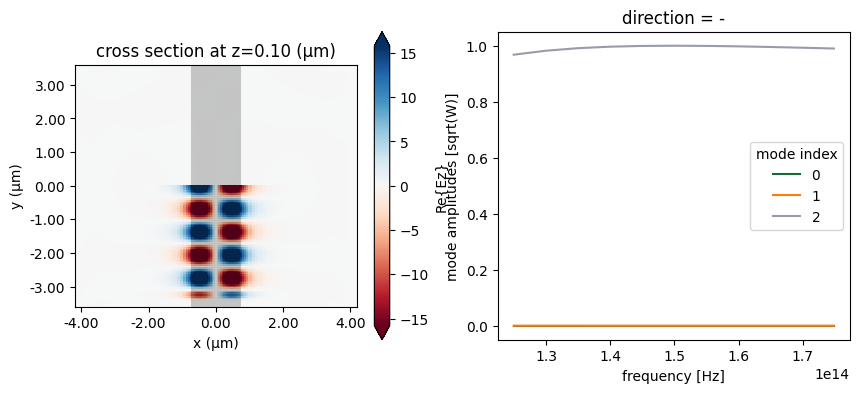

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sim_data.plot_field("field", "Ez", f=freq0, ax=ax[0])
sim_data["mode"].amps.sel(direction="-").abs.plot.line(x="f", ax=ax[1])
plt.show()

## Storing server-side computed modes

We can also use a [`ModeSolverMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSolverMonitor.html) to store the modes as they are computed on the server. This is illustrated below. We will also request in the mode specification that the modes are sorted by their `tm` polarization. In this particular simulation, TM refers to `Ez` polarization. The effect of the sorting is that modes with a `tm` polarization fraction greater than or equal to 0.5 come first in the list of modes, while still being ordered by decreasing effective index. After that, the predominantly `te`-polarized modes follow.


In [19]:
mode_spec = mode_spec.copy(
    update=dict(
        sort_spec=td.ModeSortSpec(
            filter_key="TM_fraction",
            filter_reference=0.5,
            filter_order="over",
        )
    )
)

# Update mode source to use the highest-tm-fraction mode
mode_src = mode_src.copy(update=dict(mode_spec=mode_spec))
mode_src = mode_src.copy(update=dict(mode_index=0))

# Update mode monitor to use the tm_fraction ordered mode_spec
mode_mon = mode_mon.copy(update=dict(mode_spec=mode_spec))

# New monitor to record the modes computed at the mode decomposition monitor location
mode_solver_mon = td.ModeSolverMonitor(
    center=mode_mon.center,
    size=mode_mon.size,
    freqs=mode_mon.freqs,
    mode_spec=mode_spec,
    name="mode_solver",
)

sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    structures=[waveguide],
    sources=[mode_src],
    monitors=[monitor, mode_mon, mode_solver_mon],
)

In [20]:
job = web.Job(simulation=sim, task_name="mode_simulation", verbose=True)
sim_data = job.run(path="data/simulation_data.hdf5")

14:47:57 -03 Created task 'mode_simulation' with resource_id                    
             'fdve-d20790ea-2529-4b3f-a9b5-6bf85a54335f' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=185919;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d20790ea-2529-4b3f-a9b5-6bf85a54335f\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=440860;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d20790ea-2529-4b3f-a9b5-6bf85a54335f\taskId]8;;\]8;id=185919;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d20790ea-2529-4b3f-a9b5-6bf85a54335f\=]8;;\]8;id=306955;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d20790ea-2529-4b3f-a9b5-6bf85a54335f\fdve]8;;\]8;id=185919;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d20790ea-2529-4b3f-a9b5-6bf85a54335f\-d20790ea-252]8;;\
             ]8;id=185919;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d20790ea-2529-4b3f-a9b5-6bf85a54335f\9-4b3f-a9b5-6bf85a54335f']8;;\.

             Task folder: ]8;id=871701;https://tidy3d.simulation.cloud/folders/folder-431883bc-afbb-4cc8-a95f-ddfeaeeb059a\'default']8;;\.

Output()

14:48:02 -03 Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

14:48:04 -03 status = success

Output()

14:48:15 -03 Loading simulation from data/simulation_data.hdf5

Note the different ordering of the recorded modes compared to what we saw above, with the fundamental TM mode coming first.

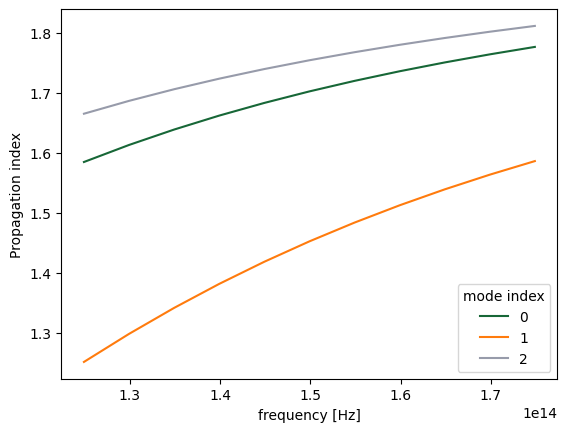

In [21]:
fig, ax = plt.subplots(1)
n_eff = sim_data["mode"].n_eff  # real part of the effective mode index
n_eff.plot.line(x="f")
plt.show()

Now the fundamental Ez-polarized mode is injected, and as before, it is the only one for which the mode monitor records any intensity.

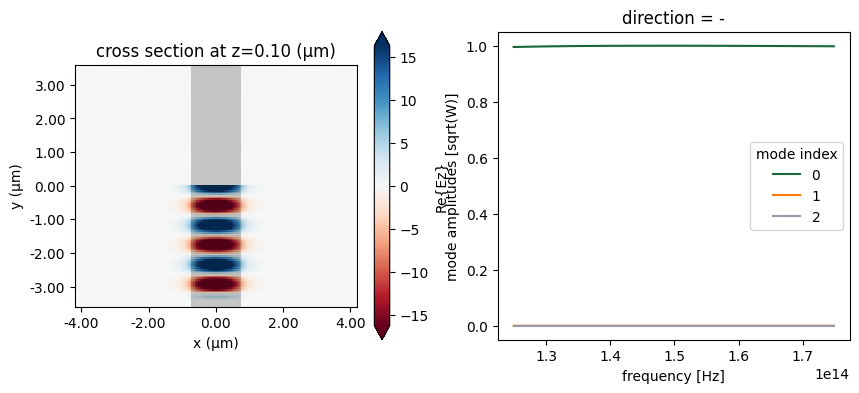

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sim_data.plot_field("field", "Ez", f=freq0, ax=ax[0])
sim_data["mode"].amps.sel(direction="-").abs.plot.line(x="f", ax=ax[1])
plt.show()

We can also have a look at the mode fields stored in the `ModeFieldMonitor`, either directly using xarray methods as above or using the Tidy3D [`SimulationData`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.SimulationData.html) built-in field plotting.

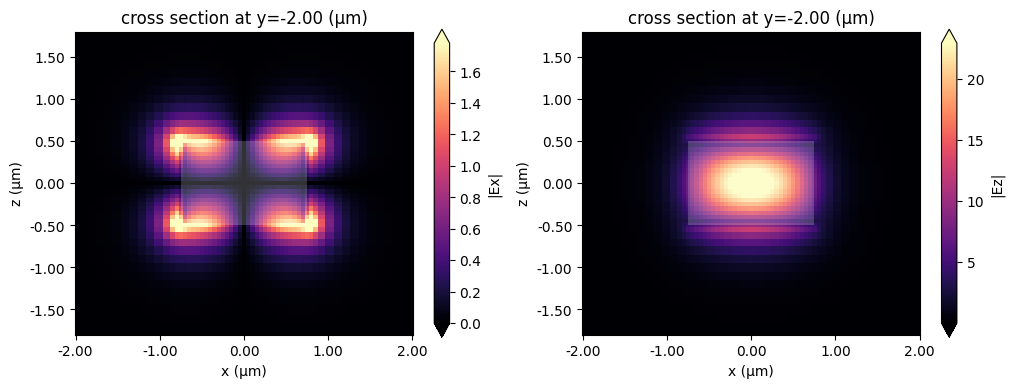

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sim_data.plot_field("mode_solver", "Ex", f=freq0, val="abs", mode_index=0, ax=ax[0])
sim_data.plot_field("mode_solver", "Ez", f=freq0, val="abs", mode_index=0, ax=ax[1])
plt.show()

## Computing modes on the server

We can also run [`ModeSimulation`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSimulation.html) on the server. We use the previous mode simulation as an example:


In [24]:
sim_data = web.run(mode_simulation, task_name="mode_simulation")
mode_data = sim_data.modes

14:48:16 -03 Created task 'mode_simulation' with resource_id                    
             'mos-28e7bdb4-980c-4de1-b2ae-36425f9cff57' and task_type 'MODE'.

Output()

14:48:19 -03 Estimated FlexCredit cost: 0.006. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

14:48:21 -03 status = success

Output()

14:48:27 -03 Loading simulation from simulation_data.hdf5

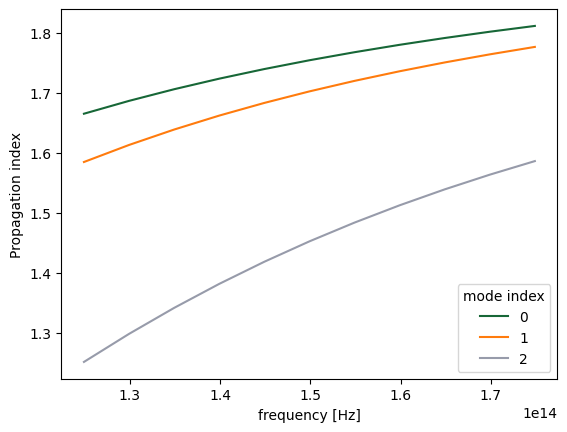

In [25]:
fig, ax = plt.subplots(1)
n_eff = mode_data.n_eff
n_eff.plot.line(x="f")
plt.show()

To demonstrate the accuracy improvement, we can show a convergence plot comparing the local and remote solvers on a waveguide that does not align with the mesh, in this case a dielectric rod.

In [26]:
from tidy3d.packaging import tidy3d_extras

tidy3d_extras["use_local_subpixel"]
td.config.simulation.use_local_subpixel = False

In [27]:
resolutions = range(10, 31, 2)
n_eff = ([], [])

cylinder = td.Structure(
    geometry=td.Cylinder(axis=1, center=(0, 0, 0), radius=0.7, length=2 * Lz),
    medium=td.Medium(permittivity=wg_permittivity),
)

dummy_source = td.UniformCurrentSource(
    size=(0, 0, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    polarization="Ex",
)

mode_spec = td.ModeSpec(
    num_modes=1,
    target_neff=2.0,
)


def create_mode_simulation(resolution):
    grid_spec = td.GridSpec.auto(min_steps_per_wvl=resolution, wavelength=wvl_um)

    return td.ModeSimulation(
        size=(Lx, Ly, Lz),
        plane=td.Box(center=(0, 0, 0), size=(4, 0, 4)),
        grid_spec=grid_spec,
        structures=[cylinder],
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
        mode_spec=mode_spec,
        freqs=[freq0],
    )


for resolution in resolutions:
    print("Solving for resolution =", resolution, flush=True)
    mode_simulation = create_mode_simulation(resolution)
    local_sim_data = mode_simulation.run_local()
    local_data = local_sim_data.modes
    n_eff[0].append(local_data.n_eff.item())

    mode_simulation = create_mode_simulation(resolution)
    server_sim_data = web.run(mode_simulation, task_name="mode_simulation", verbose=False)
    server_data = server_sim_data.modes
    n_eff[1].append(server_data.n_eff.item())

Solving for resolution = 10
Solving for resolution = 12
Solving for resolution = 14
Solving for resolution = 16
Solving for resolution = 18
Solving for resolution = 20
Solving for resolution = 22
Solving for resolution = 24
Solving for resolution = 26
Solving for resolution = 28
Solving for resolution = 30


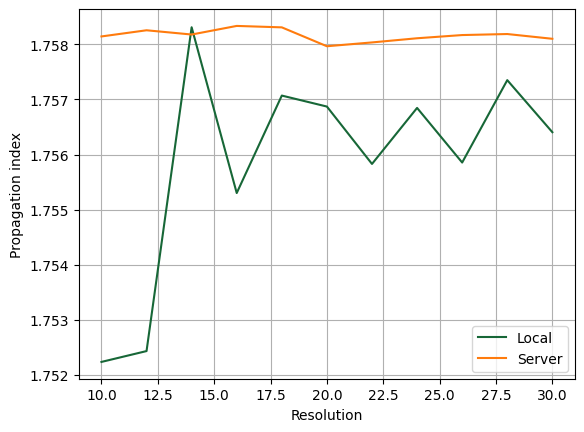

In [28]:
fig, ax = plt.subplots(1)
ax.plot(resolutions, n_eff[0], label="Local")
ax.plot(resolutions, n_eff[1], label="Server")
ax.set(xlabel="Resolution", ylabel="Propagation index")
ax.legend()
ax.grid()

## Local Subpixel Comparison

Below, we enable local subpixel averaging and repeat the local mode simulation sweep. This allows a direct comparison between:

- local without subpixel,
- local with subpixel,
- server result.

With local subpixel enabled, the local result matches the server result.

Note that it is necessary to install Tidy3D extras with `pip install "tidy3d[extras]"`.


In [29]:
# Repeat the local sweep with local subpixel enabled
from tidy3d.packaging import tidy3d_extras

tidy3d_extras["use_local_subpixel"] = True
n_eff_local_subpixel = []

for resolution in resolutions:
    print("Solving with local subpixel for resolution =", resolution, flush=True)
    mode_simulation = create_mode_simulation(resolution)
    local_subpixel_sim_data = mode_simulation.run_local()
    local_subpixel_data = local_subpixel_sim_data.modes
    n_eff_local_subpixel.append(local_subpixel_data.n_eff.item())

Solving with local subpixel for resolution = 10
Solving with local subpixel for resolution = 12
Solving with local subpixel for resolution = 14
Solving with local subpixel for resolution = 16
Solving with local subpixel for resolution = 18
Solving with local subpixel for resolution = 20
Solving with local subpixel for resolution = 22
Solving with local subpixel for resolution = 24
Solving with local subpixel for resolution = 26
Solving with local subpixel for resolution = 28
Solving with local subpixel for resolution = 30


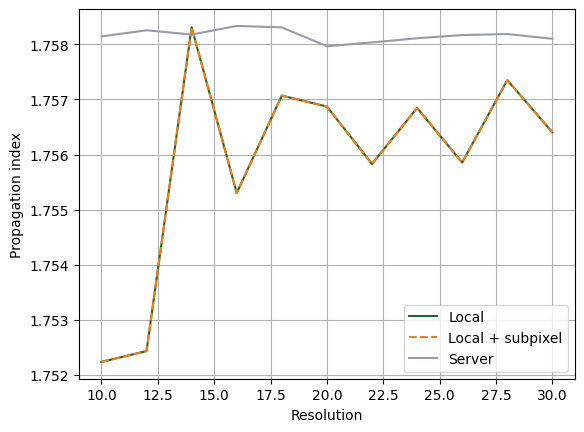

In [30]:
fig, ax = plt.subplots(1)
ax.plot(resolutions, n_eff[0], label="Local")
ax.plot(resolutions, n_eff_local_subpixel, "--", label="Local + subpixel")
ax.plot(resolutions, n_eff[1], label="Server")
ax.set(xlabel="Resolution", ylabel="Propagation index")
ax.legend()
ax.grid()
plt.show()

## Mode tracking

As is typical for eigenvalue solvers, Tidy3D’s mode simulation returns the calculated modes in the order corresponding to the magnitudes of the found eigenvalues, that is, the effective indices. Since the effective index of a mode generally depends on frequency and can become larger or smaller in magnitude relative to the effective indices of other modes, the same `mode_index` value in the returned mode simulation data may correspond to physically different modes at different frequencies.

To avoid such mismatches, [`ModeSimulation`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSimulation.html) performs sorting by default based on mode overlap values. See the [discussion on mode decomposition](https://www.flexcompute.com/tidy3d/examples/notebooks/ModalSourcesMonitors/). In other words, modes at one frequency are matched to the most similar modes at another frequency. This behavior is controlled by the `track_freq` parameter of the [`ModeSpec`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSpec.html) object. It can be set to either `None`, `"lowest"`, `"central"` (default), or `"highest"`. In the first case, no sorting is performed. In the other three cases, sorting is performed starting from the specified frequency.

Additionally, any unsorted mode simulation data returned by `ModeSimulation.run_local()` can be sorted afterwards using the `ModeSimulationData.overlap_sort()` function. This function takes the argument `track_freq` (default: `"central"`), which has the same meaning as in `ModeSpec`, and `overlap_thresh` (default: `0.9`), which defines the threshold overlap value above which a pair of spatial fields is considered to correspond to physically the same mode.

While this functionality is not expected to be used in most cases, we demonstrate it here to provide a clearer understanding of [`ModeSimulation`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSimulation.html) results. Note that for mode sources and mode monitors, sorting is always performed internally.

We start by calculating twelve modes at eleven different frequencies for a layered waveguide with the default sorting turned off.

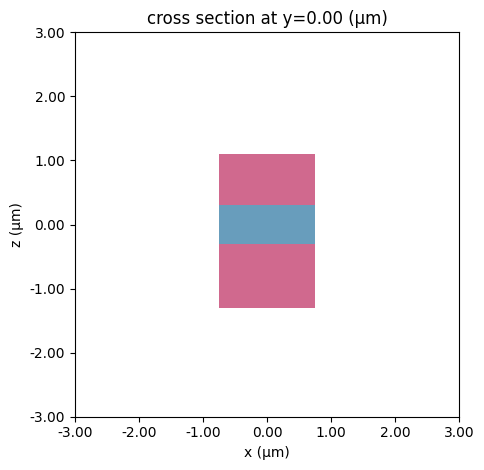

In [31]:
# bottom layer
bottom = td.Structure(
    geometry=td.Box(center=(0, 0, -0.8 * wg_height), size=(wg_width, td.inf, wg_height)),
    medium=td.Medium(permittivity=wg_permittivity * 2),
)

# top layer
top = td.Structure(
    geometry=td.Box(center=(0, 0, 0.7 * wg_height), size=(wg_width, td.inf, wg_height * 0.8)),
    medium=td.Medium(permittivity=wg_permittivity * 2),
)

# set mode spec to find 12 modes and turn off automatic mode tracking
mode_spec = td.ModeSpec(num_modes=12, track_freq=None)

# we will use a larger solver plane for this structure
plane = td.Box(center=(0, 0, 0), size=(10, 0, 10))

# 11 frequencies in +/- fwidth range
num_freqs = 11
freqs = np.linspace(freq0 - fwidth, freq0 + fwidth, num_freqs)

# make new mode simulation object and solve for modes
mode_simulation = td.ModeSimulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    structures=[waveguide, bottom, top],
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)

# visualize
mode_simulation.plot(y=0)
plt.show()

In [32]:
mode_sim_data = mode_simulation.run_local()
mode_data = mode_sim_data.modes

By inspecting the values of the effective indices, we note that some of them come very close to each other, which is a sign that some mode index values might not correspond to the same modes throughout the considered frequency range.

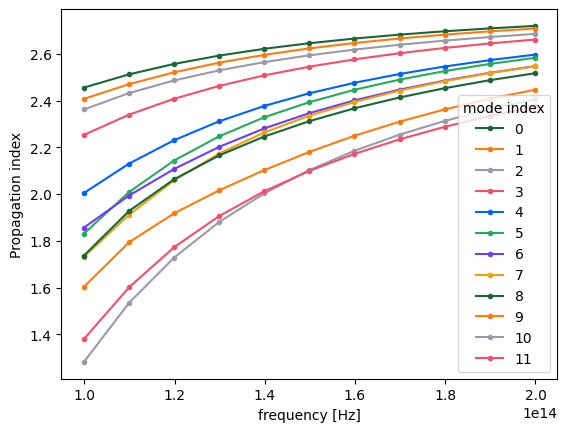

In [33]:
fig, ax = plt.subplots(1)
n_eff = mode_data.n_eff  # real part of the effective mode index
n_eff.plot.line(".-", x="f")
plt.show()

Indeed, by plotting field distributions for the calculated modes, we see mixing of modes for `mode_index` > 4.

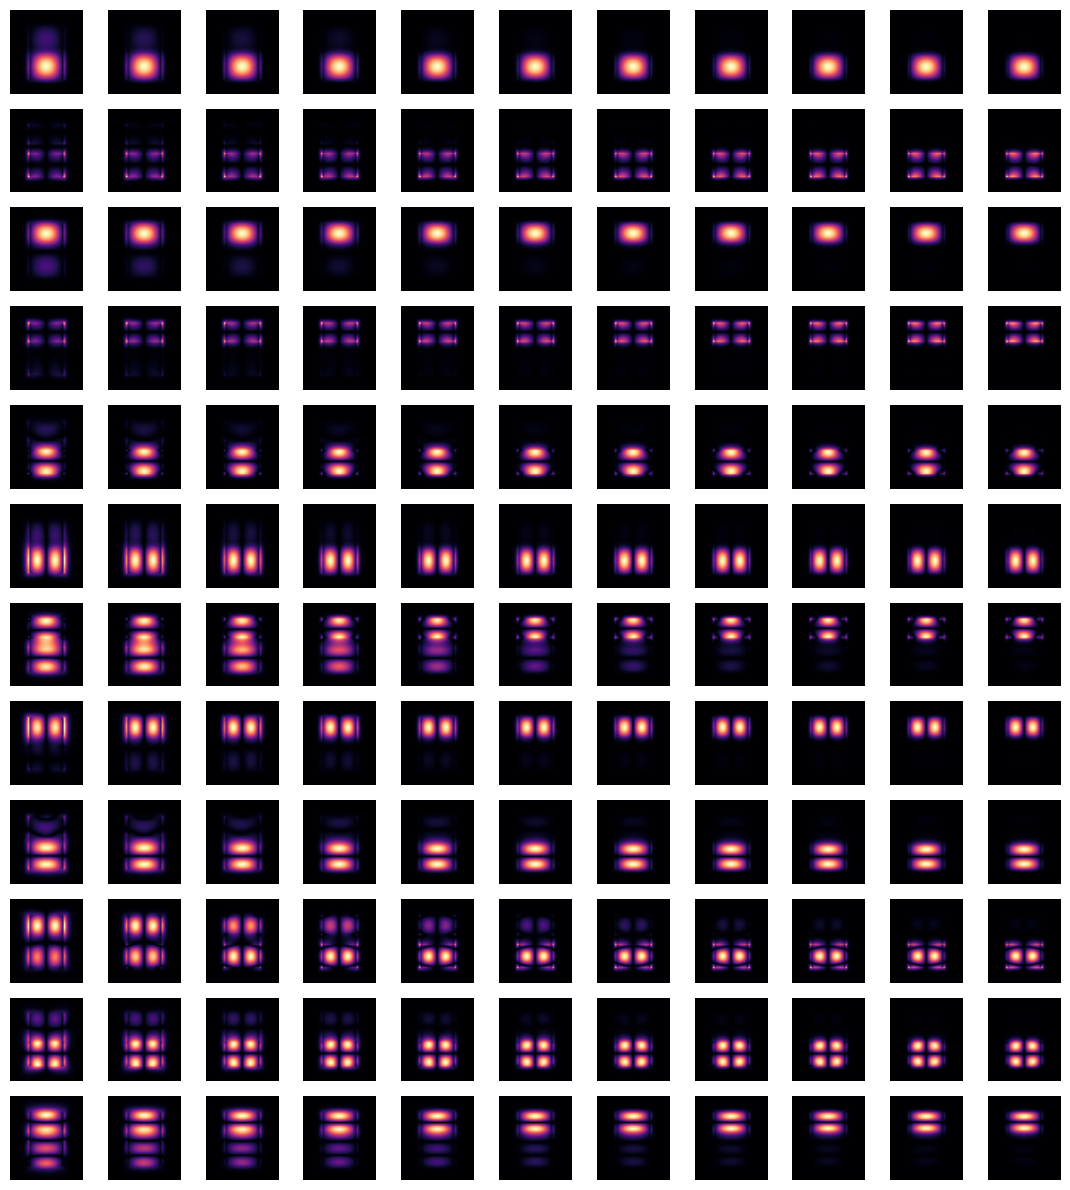

In [34]:
fig, ax = plt.subplots(
    mode_spec.num_modes,
    len(freqs),
    tight_layout=True,
    figsize=(len(freqs), mode_spec.num_modes),
)
for j in range(mode_spec.num_modes):
    for i, freq in enumerate(freqs):
        ax[j, i].imshow(
            mode_data.Ex.isel(mode_index=j, f=i, drop=True).squeeze().abs.T,
            cmap="magma",
            origin="lower",
        )
        ax[j, i].axis("off")
plt.show()

This situation can be remedied by using the `overlap_sort()` function as follows.

In [35]:
mode_data_sorted = mode_data.overlap_sort(track_freq="central")

Plotting the same information as previously, one can confirm that the modes are now matched as closely as possible.

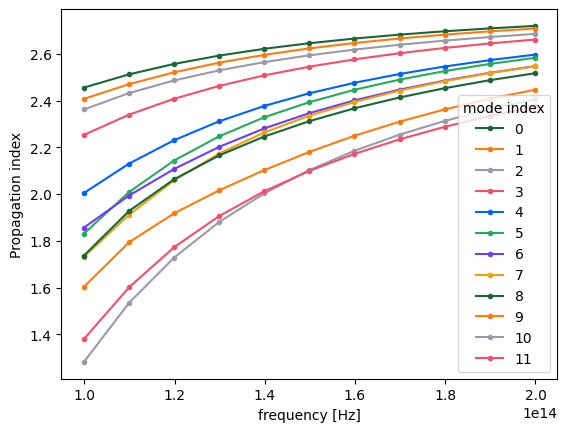

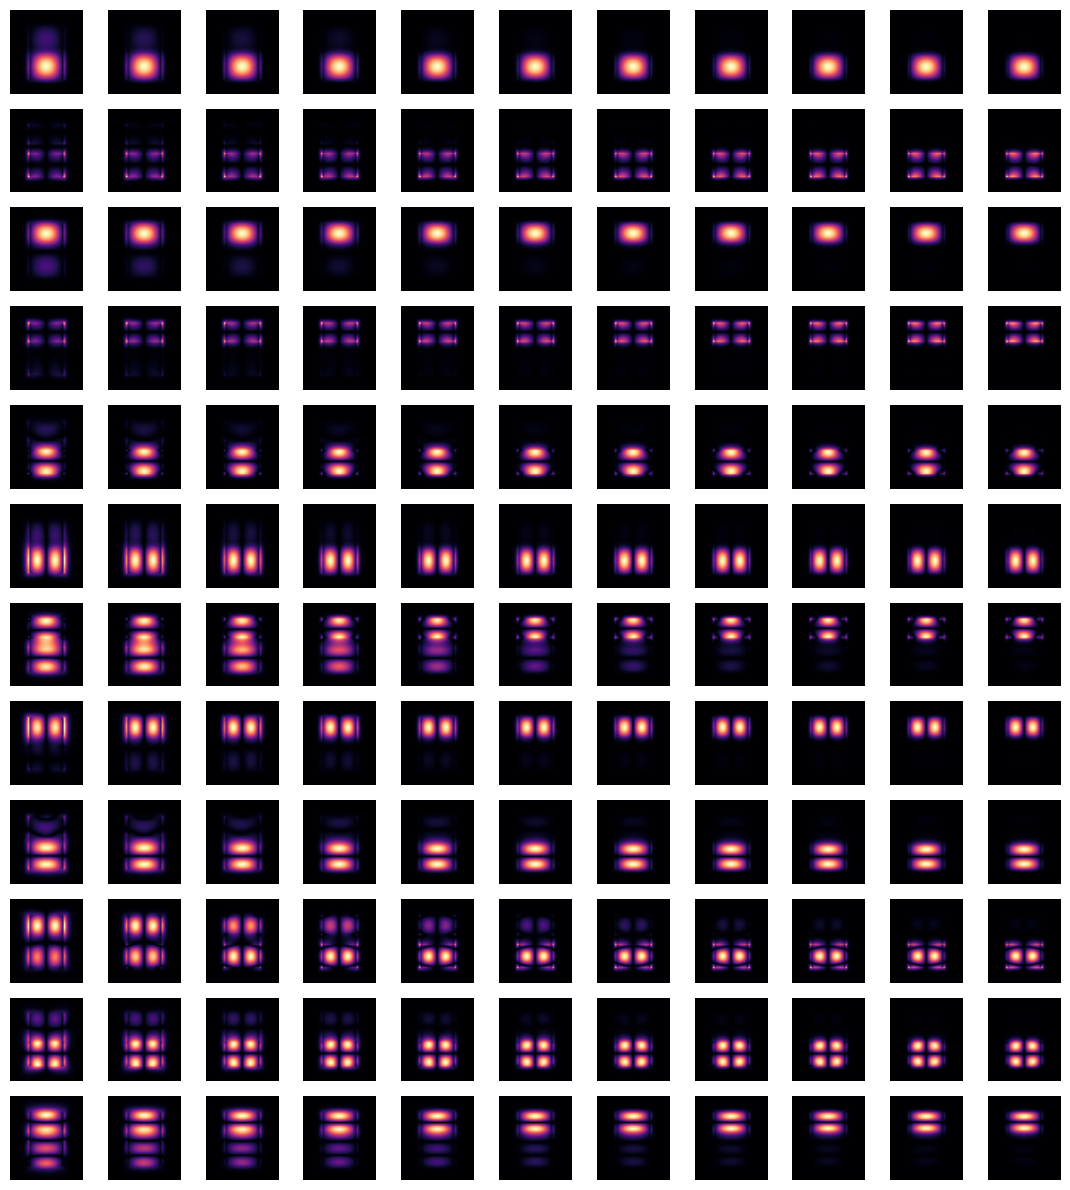

In [36]:
n_eff_sorted = mode_data_sorted.n_eff  # real part of the effective mode index
n_eff_sorted.plot.line(".-", x="f")
plt.show()

fig, ax = plt.subplots(
    mode_spec.num_modes,
    len(freqs),
    tight_layout=True,
    figsize=(len(freqs), mode_spec.num_modes),
)
for j in range(mode_spec.num_modes):
    for i, freq in enumerate(freqs):
        ax[j, i].imshow(
            mode_data_sorted.Ex.isel(mode_index=j, f=i, drop=True).squeeze().abs.T,
            cmap="magma",
            origin="lower",
        )
        ax[j, i].axis("off")
plt.show()

Note that depending on the particular situation, mode sorting, whether the default behavior or performed manually, might not successfully resolve the tracking of all modes throughout the chosen frequency range. Possible reasons include:
- A mode physically disappears at a certain frequency point.
- A mode is not included in the calculated number of modes, `num_modes`, for certain frequency points. In this case, increasing `num_modes` might alleviate the issue.
- The presence of degenerate modes at certain frequencies.


## Group Index

The mode simulation can also be used to directly calculate the group index of the calculated modes. It is important to have mode tracking enabled to avoid differentiating the wrong mode pairs around mode crossings.

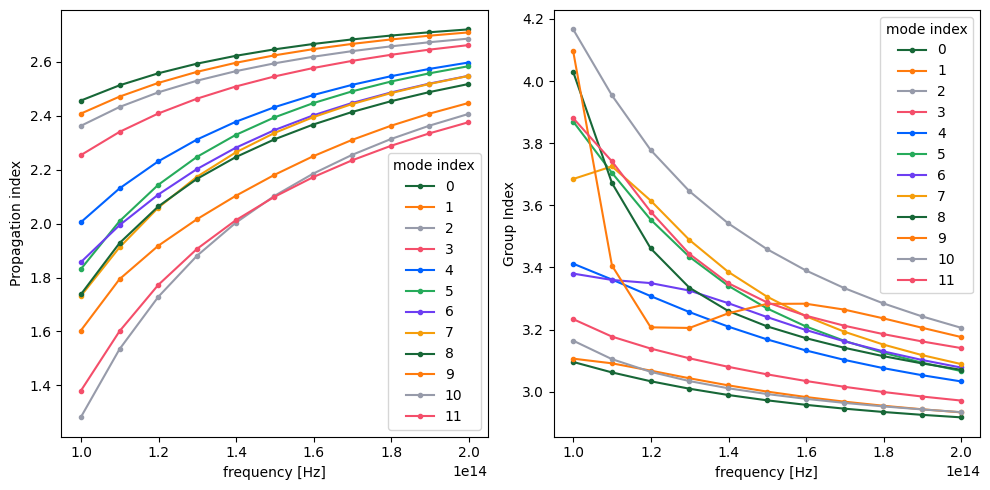

In [37]:
# Use the previous mode simulation with the appropriate settings
mode_spec = td.ModeSpec(
    num_modes=12,
    group_index_step=True,
    sort_spec=td.ModeSortSpec(track_freq="central"),
)
mode_simulation = mode_simulation.copy(update={"mode_spec": mode_spec})

mode_sim_data = mode_simulation.run_local()
mode_data = mode_sim_data.modes
n_eff = mode_data.n_eff
n_group = mode_data.n_group

_, ax = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)

n_eff.plot.line(".-", x="f", ax=ax[0])
n_group.plot.line(".-", x="f", ax=ax[1])
ax[1].set_ylabel("Group Index")
plt.show()

## Notes / Considerations

- This mode simulation runs locally with `run_local()`, which means it does not require credits.
- The same [`ModeSimulation`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSimulation.html) object can also be run on the server with `web.run(...)`.
- Symmetries are applied if they are defined in the simulation and the mode plane center sits on the simulation center.
- In cases where the number of modes, frequency points, or mode plane dimensions are large and mode tracking is not important, it may be beneficial to turn off the default mode sorting for increased computational efficiency.
